# Artificial Neural Networks — Fighting Overfitting (MNIST)

This notebook is a companion to *Classifying Handwritten Digits (MNIST)*. There we **diagnosed** overfitting: after a few epochs, training accuracy kept climbing while validation performance stalled, and validation loss began to *rise*. The network had stopped learning the task and started memorising its training set.

Here we **treat** it. Three standard treatments, in increasing order of "just stop doing the harmful thing":

1. **Weight decay (L2 regularisation)** — penalise large weights, so the network is forced to keep its solution simple. You know this idea already: it is exactly **ridge regression**, applied to every layer.
2. **Dropout** — randomly silence a fraction of neurons at each training step, so the network cannot build fragile pathways that depend on specific neurons memorising specific examples.
3. **Early stopping** — watch the validation loss and stop training when it stops improving, instead of guessing the number of epochs in advance.

**The experimental design.** To see whether a treatment works we need a control group. So we will:

1. Retrain the **baseline** network from the first notebook, but for **30 epochs** instead of 10 — deliberately provoking severe overfitting;
2. Train an otherwise **identical twin** with weight decay and dropout added, for the same 30 epochs;
3. Compare the two training histories side by side;
4. Add early stopping, so the machine finds the right stopping point itself;
5. Open the test-set vault once, at the very end.

> **A confession about test-set discipline.** The first notebook insisted the test set is touched *once*, after all decisions are made. At the end of this notebook we will evaluate *three* models on it — which, strictly, already bends the rule: if we then picked our favourite based on those test scores, the test set would start functioning as a validation set. We do it here for teaching purposes, and we will pick the "winner" from the validation curves *before* looking at the test scores. Keep the principle in mind for real projects.

## 1. Import libraries

Same toolkit as before. One addition: we fix the random seeds. Neural-network training is stochastic in several places — the initial weights are random draws, the mini-batches are reshuffled every epoch, and dropout (below) adds coin flips of its own. `set_random_seed` makes runs *more* comparable, though on a GPU results can still differ slightly between runs because some operations are non-deterministic. Expect your numbers to be close to, but not identical to, any numbers quoted in the text.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras

keras.utils.set_random_seed(42)   # weights, shuffling, dropout all draw from seeded RNGs

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


## 2. Load and pre-process the data

Exactly as in the first notebook, compressed into one cell: load MNIST, normalise pixel intensities to [0, 1], and flatten each 28×28 image into a vector of 784 values. (See the first notebook for the reasoning behind each step.)

In [2]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# Normalise to [0, 1], then flatten (n, 28, 28) -> (n, 784)
x_train = (x_train / 255.0).reshape(-1, 784)
x_test  = (x_test  / 255.0).reshape(-1, 784)

print("Training data:", x_train.shape, "  Test data:", x_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training data: (60000, 784)   Test data: (10000, 784)


## 3. The control group: the baseline network, pushed harder

We rebuild the exact architecture from the first notebook — 784 → 128 → 64 → 10, with 109,386 parameters — and train it for **30 epochs** instead of 10.

**Predict before you run.** In the first notebook, validation loss bottomed out around epoch 3–6 and had already started creeping up by epoch 10. What should 20 further epochs do to each of the four curves?

- *Training loss* should keep falling towards 0 — with ~109k parameters and 54k training images, the network has the capacity to fit its training set almost perfectly.
- *Training accuracy* should approach 100%.
- *Validation accuracy* should go roughly nowhere.
- *Validation loss* should rise steadily: the model keeps getting the same ~2% of validation images wrong, but becomes ever more *confident* in those wrong answers, and cross-entropy punishes confident errors hard.

Run it and check. (About 3–5 minutes on a Colab CPU; much faster with a GPU runtime.)

In [3]:
EPOCHS = 30   # deliberately too many — we want to watch overfitting unfold

baseline = keras.Sequential([
    keras.layers.Input(shape=(784,)),
    keras.layers.Dense(128, activation='relu'),   # hidden layer 1
    keras.layers.Dense(64, activation='relu'),    # hidden layer 2
    keras.layers.Dense(10, activation='softmax')  # output layer
], name="baseline")

baseline.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_base = baseline.fit(
    x_train, y_train,
    epochs=EPOCHS,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/30
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9249 - loss: 0.2557 - val_accuracy: 0.9655 - val_loss: 0.1107
Epoch 2/30
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9670 - loss: 0.1088 - val_accuracy: 0.9702 - val_loss: 0.0959
Epoch 3/30
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9776 - loss: 0.0742 - val_accuracy: 0.9732 - val_loss: 0.0982
Epoch 4/30
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9835 - loss: 0.0538 - val_accuracy: 0.9743 - val_loss: 0.0984
Epoch 5/30
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9872 - loss: 0.0412 - val_accuracy: 0.9717 - val_loss: 0.1069
Epoch 6/30
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9896 - loss: 0.0325 - val_accuracy: 0.9740 - val_loss: 0.1064
Epoch 7/30
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9907 - loss: 0.0283 - val_accuracy: 0.9715 - val_loss: 0.1192
Epoch 8/30
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9921 - loss: 0.0230 - 

### Reading the damage

The plots below should show the textbook overfitting picture, now in exaggerated form:

- On the **left (loss)**: training loss glides towards zero while validation loss, after its early minimum, climbs relentlessly. By epoch 30 the gap between the two curves is enormous. Everything the network "learned" after roughly epoch 5 was memorisation.
- On the **right (accuracy)**: training accuracy saturates near 100% — the network can now reproduce its training set — while validation accuracy has been flat since the first few epochs.

This is the disease. Now the treatments.

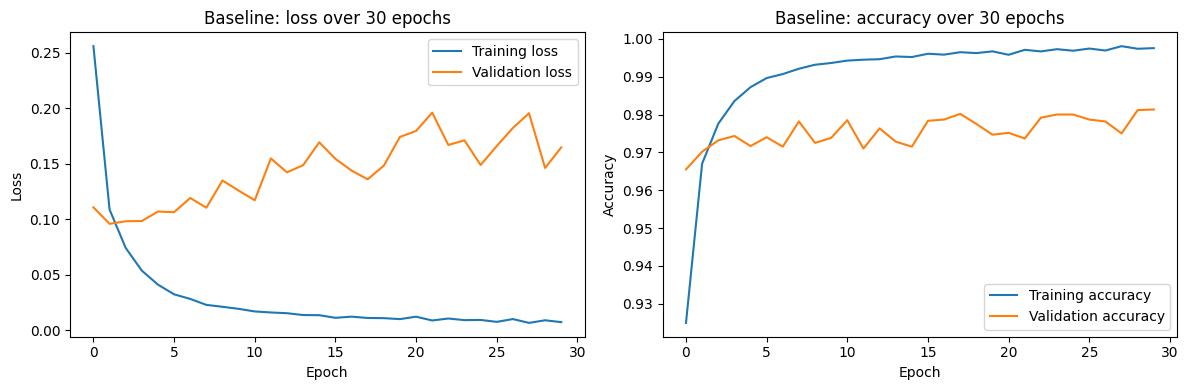

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history_base.history['loss'],     label='Training loss')
ax1.plot(history_base.history['val_loss'], label='Validation loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Baseline: loss over 30 epochs')
ax1.legend()

ax2.plot(history_base.history['accuracy'],     label='Training accuracy')
ax2.plot(history_base.history['val_accuracy'], label='Validation accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Baseline: accuracy over 30 epochs')
ax2.legend()

plt.tight_layout()
plt.show()

## 4. Treatment 1: weight decay — ridge regression for networks

**The idea.** Add a penalty to the loss function that grows with the size of the weights:

$$\text{Loss} = \underbrace{\text{cross-entropy}}_{\text{fit the data}} \; + \; \lambda \sum_j w_j^2$$

This is **exactly the ridge penalty** you know from regression, applied to every weight in every layer. The network now faces a trade-off: reducing the cross-entropy is only worth it if it does not require extreme weights. (In the deep-learning literature the same idea appears as "weight decay", because with plain gradient descent the penalty's gradient, $2\lambda w_j$, shrinks — *decays* — each weight a little at every update step.)

**Why do small weights fight overfitting?** Memorising an individual training image requires the network to react strongly to that image's specific pixel pattern — which takes large, finely-tuned weights. With weights kept small, the network's output changes only gradually as the input changes, so it *cannot* carve out special responses for individual examples. It is forced to learn only patterns that are supported by many images at once. Same intuition as in ridge regression: shrinkage trades a little bias for a large reduction in variance.

**The knob.** $\lambda$ (Keras argument `l2(...)`) controls the strength. Too small → no effect; too large → the network *underfits*, keeping weights so small it cannot even learn the real patterns. We use $\lambda = 10^{-4}$, a standard starting point. Note that $\lambda$ is a **hyperparameter**: it is not learned by gradient descent but chosen by us — and if we tune it, we must tune it on *validation* performance, never on test performance.

**One bookkeeping consequence.** Keras reports the *total* loss — cross-entropy **plus** penalty. The regularised model's training loss is therefore not directly comparable to the baseline's (it carries the penalty term on top), and it will not approach zero even if classification becomes perfect. The `val_accuracy` column remains directly comparable, and that is mostly what we will read.

## 5. Treatment 2: dropout — training under sabotage

**The idea.** During training, before each weight update, every neuron in a dropout layer is silenced (set to 0) independently with probability $p$ — here $p = 0.3$. Which neurons are silenced is re-randomised for *every mini-batch*. At evaluation and prediction time, dropout is switched off and the full network is used.

**Why does randomly damaging the network help?** Two complementary intuitions:

- **No fragile pathways.** Memorising a particular training image means routing its recognition through a specific chain of neurons. Under dropout, any such chain is broken at random 30% of the time, so memorisation strategies keep failing. Patterns that are stored *redundantly*, across many neurons — which is only economical for regularities shared by many images — survive the sabotage. Dropout selectively punishes memorisation.
- **An ensemble in disguise.** Each mini-batch trains a different randomly-thinned sub-network. Over 30 epochs, the procedure trains a huge collection of overlapping sub-networks that share weights; the full network at prediction time behaves approximately like an *average* of them. Averaging many noisy models is a classic variance-reduction trick (it is why random forests beat single trees).

**A display quirk to expect below.** During training, the `accuracy` column is computed *with the sabotage active*, while `val_accuracy` is computed with dropout off. So don't be surprised to see **training accuracy sitting *below* validation accuracy** — the network takes its exams intact but does its homework with 30% of its neurons missing. This is normal with dropout, and it is a useful reminder that the two columns are not measured under the same conditions.

**The knob.** The dropout rate $p$: 0.2–0.5 is the usual range for hidden layers. Higher = stronger regularisation, but too high starves the network of capacity.

## 6. The treatment group: an identical twin, regularised

Same architecture, same optimiser, same 30 epochs — the only changes are `kernel_regularizer=l2(1e-4)` on the hidden layers and a `Dropout(0.3)` after each of them.

Check `model.summary()` below: the parameter count is **unchanged** at 109,386. Regularisation does not remove parameters — it constrains how they are *used*. Dropout layers have no weights of their own (they just flip coins), and the L2 penalty is part of the loss, not the architecture.

In [5]:
from tensorflow.keras import regularizers

regularised = keras.Sequential([
    keras.layers.Input(shape=(784,)),
    keras.layers.Dense(128, activation='relu',
                       kernel_regularizer=regularizers.l2(1e-4)),  # ridge penalty on these weights
    keras.layers.Dropout(0.3),                                     # silence 30% of these 128, at random
    keras.layers.Dense(64, activation='relu',
                       kernel_regularizer=regularizers.l2(1e-4)),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(10, activation='softmax')                   # output layer: no dropout here
], name="regularised")

regularised.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

regularised.summary()

Model: "regularised"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
history_reg = regularised.fit(
    x_train, y_train,
    epochs=EPOCHS,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/30
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8724 - loss: 0.4474 - val_accuracy: 0.9632 - val_loss: 0.1642
Epoch 2/30
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9389 - loss: 0.2480 - val_accuracy: 0.9703 - val_loss: 0.1403
Epoch 3/30
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9490 - loss: 0.2172 - val_accuracy: 0.9772 - val_loss: 0.1291
Epoch 4/30
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9562 - loss: 0.1999 - val_accuracy: 0.9763 - val_loss: 0.1329
Epoch 5/30
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9584 - loss: 0.1921 - val_accuracy: 0.9752 - val_loss: 0.1344
Epoch 6/30
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9617 - loss: 0.1830 - val_accuracy: 0.9763 - val_loss: 0.1334
Epoch 7/30
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9622 - loss: 0.1784 - val_accuracy: 0.9787 - val_loss: 0.1325
Epoch 8/30
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9643 - loss: 0.1775 -

## 7. Side-by-side comparison: did the treatment work?

The plots overlay both models: **baseline in red, regularised in blue; training curves dashed, validation curves solid.** What to look for:

**1. The validation loss curves tell the main story (left panel).** The baseline's validation loss (solid red) bottoms out early and then climbs throughout — the overfitting signature. The regularised model's validation loss (solid blue) should descend and then stay roughly flat at a *lower* level. The treatment doesn't make the network better at its training set — it stops the slide that came *after* genuine learning ended.

**2. The generalisation gap shrinks (both panels).** For the baseline, the dashed and solid red curves diverge dramatically. For the regularised model, dashed and solid blue stay close together — indeed, dropout's display quirk means dashed blue (training) may sit *below* solid blue (validation) for accuracy, and the regularised training loss stays visibly above zero (it includes the L2 penalty, and it is measured under sabotage).

**3. What regularisation does *not* do.** Look at the two solid curves in the accuracy panel: the regularised model's validation accuracy should be similar to or slightly better than the baseline's — think a few tenths of a percentage point, not a leap. Regularisation is not a magic accuracy booster; on a dataset this large and a task this easy, the baseline was already generalising decently. What we bought is *robustness*: a model whose performance does not depend on stopping at exactly the right epoch, whose confidence is less inflated, and a training procedure that would remain safe if we let it run even longer. On smaller or noisier datasets — common in social science — the accuracy payoff from regularisation is typically far larger.

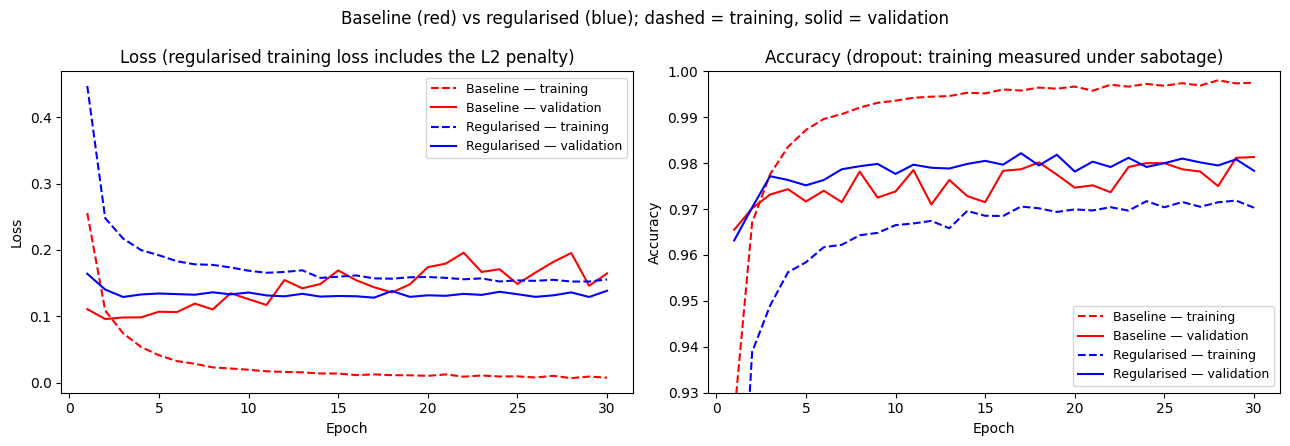

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

epochs_range = range(1, EPOCHS + 1)

# --- Loss ---
ax1.plot(epochs_range, history_base.history['loss'],     'r--', label='Baseline — training')
ax1.plot(epochs_range, history_base.history['val_loss'], 'r-',  label='Baseline — validation')
ax1.plot(epochs_range, history_reg.history['loss'],      'b--', label='Regularised — training')
ax1.plot(epochs_range, history_reg.history['val_loss'],  'b-',  label='Regularised — validation')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Loss (regularised training loss includes the L2 penalty)')
ax1.legend(fontsize=9)

# --- Accuracy ---
ax2.plot(epochs_range, history_base.history['accuracy'],     'r--', label='Baseline — training')
ax2.plot(epochs_range, history_base.history['val_accuracy'], 'r-',  label='Baseline — validation')
ax2.plot(epochs_range, history_reg.history['accuracy'],      'b--', label='Regularised — training')
ax2.plot(epochs_range, history_reg.history['val_accuracy'],  'b-',  label='Regularised — validation')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_ylim(0.93, 1.0)   # zoom in on the interesting region
ax2.set_title('Accuracy (dropout: training measured under sabotage)')
ax2.legend(fontsize=9)

plt.suptitle('Baseline (red) vs regularised (blue); dashed = training, solid = validation',
             fontsize=12)
plt.tight_layout()
plt.show()

## 8. Treatment 3: early stopping — let the machine pick the stopping point

Even with weight decay and dropout, we are still *guessing* the number of epochs. Early stopping removes the guess: monitor validation loss after every epoch, and when it has stopped improving, halt and rewind.

The Keras callback below has three important arguments:

- `monitor='val_loss'` — watch validation loss, not training loss (training loss almost always keeps improving) and not validation accuracy (Section 8 of the first notebook showed loss detects overfitting earlier).
- `patience=5` — tolerate 5 consecutive epochs without improvement before stopping. Validation loss is noisy; without patience we would quit at the first unlucky epoch.
- `restore_best_weights=True` — after stopping, roll the network back to the weights from the best epoch, not the last one. Without this flag you keep the weights from 5 epochs *past* the optimum.

Note the interplay with the validation split: early stopping is a *decision* made using validation data — a textbook example of why validation scores are optimistically biased as estimates of final performance, and why the test set must stay locked until the end.

We rebuild the regularised model from scratch first. Calling `fit()` on an already-trained model would *continue* training it, and our comparison would be meaningless.

In [8]:
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1               # report the epoch at which training stops
)

# Rebuild from scratch — fresh random weights, not a continuation of Section 6
regularised_es = keras.Sequential([
    keras.layers.Input(shape=(784,)),
    keras.layers.Dense(128, activation='relu',
                       kernel_regularizer=regularizers.l2(1e-4)),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(64, activation='relu',
                       kernel_regularizer=regularizers.l2(1e-4)),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(10, activation='softmax')
], name="regularised_early_stopping")

regularised_es.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_es = regularised_es.fit(
    x_train, y_train,
    epochs=100,             # an upper bound, not a target — early stopping decides
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

n_run  = len(history_es.history['loss'])
n_best = n_run - early_stop.patience
print(f"\nRan {n_run} epochs; kept the weights from epoch {n_best}.")

Epoch 1/100
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.8757 - loss: 0.4449 - val_accuracy: 0.9642 - val_loss: 0.1616
Epoch 2/100
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9372 - loss: 0.2508 - val_accuracy: 0.9733 - val_loss: 0.1399
Epoch 3/100
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9500 - loss: 0.2126 - val_accuracy: 0.9733 - val_loss: 0.1350
Epoch 4/100
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9549 - loss: 0.1982 - val_accuracy: 0.9745 - val_loss: 0.1359
Epoch 5/100
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9591 - loss: 0.1866 - val_accuracy: 0.9773 - val_loss: 0.1293
Epoch 6/100
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9607 - loss: 0.1820 - val_accuracy: 0.9773 - val_loss: 0.1331
Epoch 7/100
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9632 - loss: 0.1781 - val_accuracy: 0.9788 - val_loss: 0.1264
Epoch 8/100
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9652 - loss: 

## 9. The final exam: all three models on the test set

Now we open the vault. Based on the *validation* curves alone, our pick is the early-stopped regularised model: it matches the 30-epoch regularised model's validation performance at a fraction of the training cost, and both dominate the baseline's late-epoch validation loss. That choice is made — *now* we look at the test set.

Expected pattern:

- **Accuracy** should be broadly similar across all three models (within a few tenths of a percentage point) — MNIST with a dense network plateaus around 97–98% no matter how carefully we regularise.
- **Test loss** is where the treatments visibly pay off: the baseline's test loss should be markedly higher, because 30 epochs of memorisation made it grossly over-confident, and cross-entropy prices over-confidence. The regularised models make roughly as many errors, but with more honest probabilities — recall the calibration warning in Section 10 of the first notebook.

The general lesson transfers beyond MNIST: regularisation buys the most when data is scarce, noisy, or the network is large relative to the sample — precisely the regime of most applied social-science problems.

In [9]:
results = {}
for m in (baseline, regularised, regularised_es):
    loss, acc = m.evaluate(x_test, y_test, verbose=0)
    results[m.name] = (loss, acc)

print(f"{'Model':<32} {'Test loss':>10} {'Test accuracy':>15}")
print("-" * 59)
for name, (loss, acc) in results.items():
    print(f"{name:<32} {loss:>10.4f} {acc * 100:>14.2f}%")

Model                             Test loss   Test accuracy
-----------------------------------------------------------
baseline                             0.1429          97.83%
regularised                          0.1423          97.37%
regularised_early_stopping           0.1348          97.48%


## 10. Summary and things to try

**What we did:**

1. Retrained the baseline network for 30 epochs and provoked severe overfitting: training loss near zero, validation loss climbing steadily.
2. Added **weight decay** (the ridge penalty, $\lambda = 10^{-4}$, on every hidden-layer weight) and **dropout** (silencing 30% of hidden neurons at random during training). The generalisation gap collapsed and validation loss stayed low and flat.
3. Added **early stopping** (patience 5, restoring the best weights), which found a good stopping point automatically instead of our guessing an epoch count.
4. Confirmed on the test set: similar accuracy across models, but markedly lower loss for the regularised models — same error *rate*, more honest confidence.

**The one-sentence takeaway:** regularisation rarely makes a big model much more accurate on easy, plentiful data — it makes performance *robust* to training decisions, and it matters most when data is scarce relative to model capacity.

**Exercises — each isolates one knob:**

- **Ablate.** Train two more twins: dropout only (no L2) and L2 only (no dropout), 30 epochs each. Which of the two treatments does more of the work here?
- **Overdose on weight decay.** Set the L2 strength to $10^{-2}$. Predict the four curves before running: this is *underfitting* — the penalty overwhelms the data, and both training and validation performance should suffer.
- **Overdose on dropout.** Try `Dropout(0.7)`. How many epochs does the network now need to reach 97% validation accuracy, and does it get there at all?
- **Stress-test with less data.** Train the baseline and the regularised twin on only 5,000 training images (`x_train[:5000]`, `y_train[:5000]`). With data scarce, the accuracy gap between them should open up — regularisation earns its keep when samples are few.
- **Tune the patience.** Rerun early stopping with `patience=1` and `patience=10`. Which epoch's weights does each keep, and how do their test losses compare? (Do this comparison on validation loss — deciding it on test loss would be exactly the sin Section 9 warned about.)